1.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2.

In [3]:
mpg_df = pd.read_excel('auto_mpg.xlsx')

3.

In [4]:
mpg_df.rename(columns={'mpg':'연비', 'cylinders':'실린더 수',
                       'displacement': '배기량', 'horsepower': '마력',
                       'weight': '차량 무게', 'acceleration': '가속 성능',
                       'model_year': '차량 출시 연도', 'origin': '제조 국가 코드',
                       'name': '차량 이름'}, inplace=True)

4.

In [6]:
del_df = mpg_df.dropna()

5.

In [7]:
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='마력', ylabel='연비'>

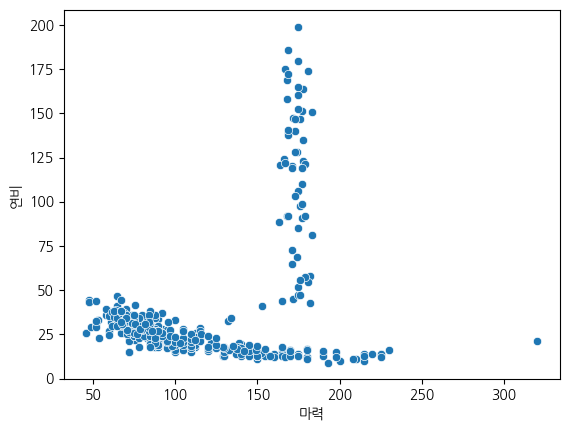

In [8]:
sns.scatterplot(data=del_df, x='마력', y='연비')

In [9]:
del_df.drop(del_df[(del_df['마력'] >= 150) & (del_df['연비'] > 50)].index, inplace=True)

/tmp/ipykernel_13502/3732620378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df.drop(del_df[(del_df['마력'] >= 150) & (del_df['연비'] > 50)].index, inplace=True)


6.

In [10]:
col_list = ['배기량','마력','차량 무게','가속 성능']

<Axes: >

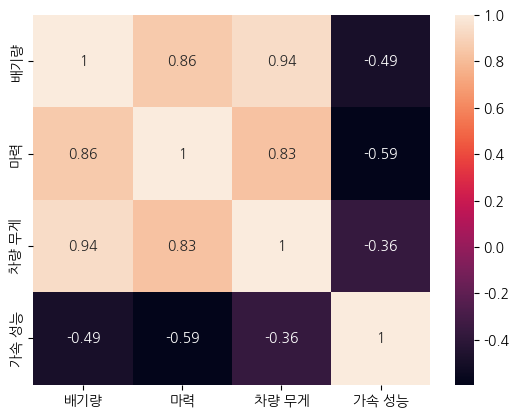

In [11]:
sns.heatmap(data=del_df[col_list].corr(), annot=True)

In [ ]:
답06 = '3'

7.

In [12]:
clear_df = del_df.drop(columns=['차량 무게', '차량 출시 연도', '제조 국가 코드', '차량 이름'])

8.

In [13]:
encoding_df = pd.get_dummies(data=clear_df, columns=['실린더 수'], drop_first=True)

9.

In [14]:
from sklearn.model_selection import train_test_split

X = encoding_df.drop(columns=['연비'])
y = encoding_df['연비']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

10.

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

11.

In [17]:
from sklearn.svm import SVR

In [18]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)

svr.fit(X_train, y_train)

SVR(epsilon=0.2)

12.

In [19]:
from sklearn.ensemble import RandomForestRegressor

In [20]:
rfr = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=7, random_state=42)

rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=7, n_estimators=200,
                      random_state=42)

13.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
tf.random.set_seed(42)

In [23]:
model = Sequential()
model.add(Dense(32, activation='tanh', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(24, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='tanh'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(1,activation='linear'))

model.compile(optimizer='rmsprop', loss='mean_absolute_error', metrics=['mean_squared_error'])

model.fit(X_train, y_train, epochs=50, batch_size=8)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.1233 - mean_squared_error: 592.9386   
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.9178 - mean_squared_error: 535.7979
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.5861 - mean_squared_error: 481.3428 
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 19.2049 - mean_squared_error: 431.4538 
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.3693 - mean_squared_error: 403.5371
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.8348 - mean_squared_error: 383.8945 
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.3994 - mean_squared_error: 368.3215
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.0065 - mean_squared_error: 354.8856
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.6321 - mean_squared_error: 342.2887 
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.2919 - mean_squared_error: 331.1239 
Epoch 11/50
41/41 ━━━━━━━━━━━━━━

14.

In [24]:
simul_data = np.array([[200.0, 95.0, 15.0, 1, 0, 0, 0]])

In [25]:
simul_data = scaler.transform(simul_data)

deep_pre = model.predict(simul_data)
print(deep_pre)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[20.314766]]
